# Setup

In [17]:
import math
import pickle as pk
import pathlib

import torch
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, silhouette_score
import kmedoids
import seaborn as sns
import matplotlib.pyplot as plt

from data import MET_Data
import utils

In [ ]:
device = "cpu"

merge_map = utils.get_tree_merge_map("../data/meta/tree_Mouse_ALM-VISp_2018.csv", "n3")

def get_merge_func(index, merge_map = merge_map):
    merge_func = np.vectorize(lambda elem: merge_map[elem][index]) 
    return merge_func

def get_model(model_path):
    experiment = utils.load_jit_folds(model_path, get_checkpoints = False)
    encoders = {fold: {modal: arms["enc"].to(device) for (modal, arms) in fold_dict["best"].model_dict.items()}
                for (fold, fold_dict) in experiment["folds"].items()}
    decoders = {fold: {modal: arms["dec"].to(device) for (modal, arms) in fold_dict["best"].model_dict.items()}
                for (fold, fold_dict) in experiment["folds"].items()}
    mappers = {fold: {tuple(modal_str.split("-")): mapper.to(device) for (modal_str, mapper) in fold_dict["best"].mappers.items()}
                     if fold_dict["best"].mappers else {}
               for (fold, fold_dict) in experiment["folds"].items()}
    return (encoders, decoders, mappers)

def get_data():
    data_keys = {"logcpm": "logcpm", "pca-ipfx": "pca-ipfx", "arbors": "arbors"}
    met_data = MET_Data("../data/neurons.hdf5", **data_keys)
    for form in ["logcpm", "pca-ipfx", "arbors"]:
        met_data.cache_data(form)
    raw_data = met_data.query(formats = [("logcpm", "pca-ipfx", "arbors")], outputs = ["logcpm", "pca-ipfx", "arbors", "cluster_label"])
    cluster_labels = np.char.strip(raw_data["cluster_label"])
    data = {form: torch.from_numpy(raw_data[form]).float().to(device) for form in ["logcpm", "pca-ipfx", "arbors"]}
    return (data, cluster_labels)

def get_model_outputs(data, encoders, decoders, mappers):
    forms = {"T": "logcpm", "E": "pca-ipfx", "M": "arbors"}
    with torch.no_grad():
        modal_latent = {fold: {modal: encoder({forms[modal]:data[forms[modal]]}) for (modal, encoder) in fold_dict.items()} 
                        for (fold, fold_dict) in encoders.items()}
        mapped_recons = {fold: {(in_m, out_m): decoders[fold][out_m](mapper(modal_latent[fold][in_m][0])[0])[forms[out_m]] 
                                for ((in_m, out_m), mapper) in fold_dict.items()}
                        for (fold, fold_dict) in mappers.items()} 
        direct_recons = {fold: {(in_m, in_m): decoder(modal_latent[fold][in_m][0])[forms[in_m]] 
                                for (in_m, decoder) in fold_dict.items()}
                        for (fold, fold_dict) in decoders.items()}
        recons = {fold: {**direct_recons[fold], **mapped_recons[fold]} for fold in direct_recons}

    (means, transfs, eig_vals, eig_vecs, rotations) = ({}, {}, {}, {}, {})
    with torch.no_grad():
        for (fold, fold_dict) in recons.items():
            for (in_modal, out_modal) in fold_dict:
                (mean, transf) = modal_latent[fold][in_modal]
                modals = (in_modal, out_modal)
                if in_modal != out_modal:
                    (mean, transf) = mappers[fold][modals](mean)
                (means.setdefault(fold, {})[modals], transfs.setdefault(fold, {})[modals]) = (mean, transf)
                covs = torch.einsum("nij,nkj->nik", transf, transf)
                (eig_vals.setdefault(fold, {})[modals], eig_vecs.setdefault(fold, {})[modals]) = torch.linalg.eigh(covs)
                rotations.setdefault(fold, {})[modals] = 180*torch.atan2(eig_vecs[fold][modals][:, 1, 1], eig_vecs[fold][modals][:, 1, 0])/np.pi
    return (means, transfs, recons)

def get_euclidean_distance(z_means, source_i, target_i, **kwargs):
    diff_vectors = z_means[source_i, None] - z_means[target_i]
    dist = torch.linalg.norm(diff_vectors, dim = -1)
    return dist

def get_tree_labels(tree_children, true_labels, merge_list):
    num_samples = len(true_labels)
    parent_map = [{child_1: i, child_2: i} for (i, (child_1, child_2)) in enumerate(tree_children, num_samples)]
    cluster_indices = [np.arange(num_samples)]
    for merge_dict in parent_map:
        cluster_indices.append(np.asarray([merge_dict.get(i, i) for i in cluster_indices[-1]]))
    pred_clusters = []
    for label_merge in merge_list:
        target_labels = get_merge_func(label_merge)(true_labels)
        label_map = {label:i for (i, label) in enumerate(np.unique(target_labels))}
        pred_clusters.append(cluster_indices[-len(label_map)])
    return pred_clusters

def get_scores(true_labels, pred_labels, score_func):
    scores = {}
    for (method, method_dict) in pred_labels.items():
        for ((in_modal, out_modal), modal_dict) in method_dict.items():
            for (merge, merge_dict) in modal_dict.items():
                print(f"Generating {method} scores: {in_modal} -> {out_modal}                     ", end = "\r")
                true_merged = get_merge_func(merge)(true_labels)
                label_map = {label:i for (i, label) in enumerate(np.unique(true_merged))}
                true_indices = np.asarray([label_map[label] for label in true_merged])
                score = np.mean([score_func(true_indices, pred) for pred in merge_dict.values()])
                scores.setdefault(method, {}).setdefault((in_modal, out_modal), {})[merge] = score
    return scores

def get_silhouette(X, labels):
    silhouettes = {}
    for (method, method_dict) in labels.items():
        for ((in_modal, out_modal), modal_dict) in method_dict.items():
            for (merge, merge_dict) in modal_dict.items():
                print(f"Generating {method} silhouettes: {in_modal} -> {out_modal} merge {merge}                     ", end = "\r")
                fold_scores = [silhouette_score(X, label) for label in merge_dict.values()
                               if np.unique(label).size > 1]
                if fold_scores:
                    silhouettes.setdefault(method, {}).setdefault((in_modal, out_modal), {})[merge] = np.mean(fold_scores)
    return silhouettes

def load_labels(label_path, methods = None, modals = None):
    with open(label_path, "rb") as target:
        results = pk.load(target)
        (pred_labels, true_labels) = (results["pred_labels"], results["true_labels"])
        pred_labels = {method: dct for (method, dct) in pred_labels.items() if not methods or method in methods}
        for method in pred_labels:
            pred_labels[method] = {modal: dct for (modal, dct) in pred_labels[method].items() if not modals or modal in modals}
    return (pred_labels, true_labels)

In [12]:
(data, cluster_labels) = get_data()

Caching logcpm...
Caching pca-ipfx...
Caching arbors...


# Latent Visualization

In [ ]:

(encoders, decoders, mappers) = get_model("../results/baselines/met_2d_mse")
(means, transfs, recons) = get_model_outputs(data, encoders, decoders, mappers)
(pred_labels, true_labels) = load_labels("../data/clustering/cluster_met_2d.pk")


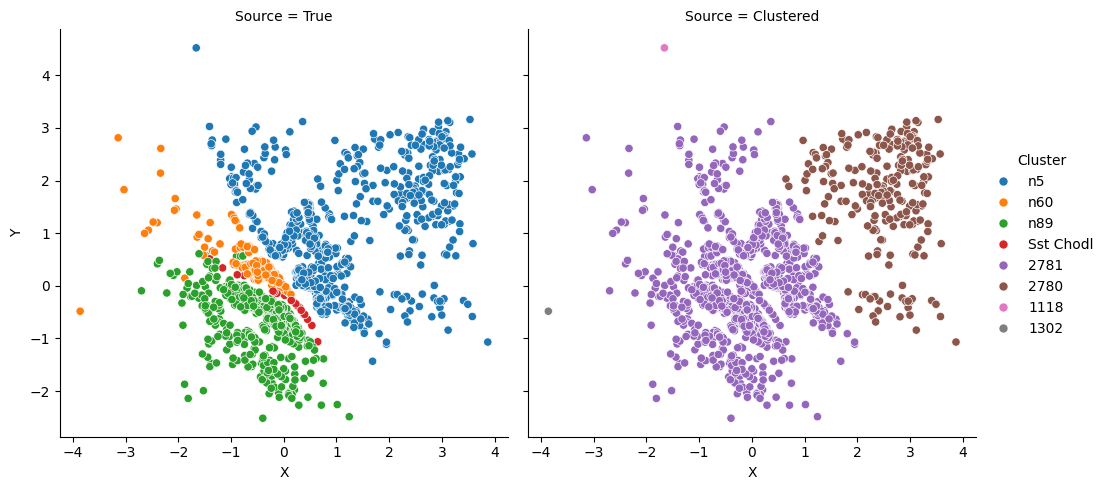

In [14]:
modals = ("T", "T")
fold = 3
merge = 99
method = "eucl"

true_merged = get_merge_func(merge)(true_labels)
pred_merged = pred_labels[method][modals][merge][fold]
latent = means[fold][modals]
sns.relplot({"X": np.tile(latent[:, 0], 2), "Y": np.tile(latent[:, 1], 2), 
             "Cluster": np.concatenate([true_merged, pred_merged]), "Source": len(latent)*["True"] + len(latent)*["Clustered"]},
            x = "X", y = "Y", hue = "Cluster", col = "Source")
plt.show()

# Weighting

In [ ]:
(score_name, score_func) = ("Rand Score", adjusted_rand_score)
cluster_paths = {
    "1": "../data/clustering/cluster_1_10d.pk",
    "1/2": "../data/clustering/cluster_2_10d.pk",
    "1/10": "../data/clustering/cluster_10_10d.pk",
    "1/100": "../data/clustering/cluster_100_10d.pk",
    "0": "../data/clustering/cluster_allt_10d.pk",
    "Unimodal": "../data/clustering/cluster_t_10d.pk"}
labels = {weight: load_labels(path, modals = {("T", "T")}) for (weight, path) in cluster_paths.items()}

## Rand Scores

In [6]:
scores = {weight: get_scores(true, pred, score_func) for (weight, (pred, true)) in labels.items()}

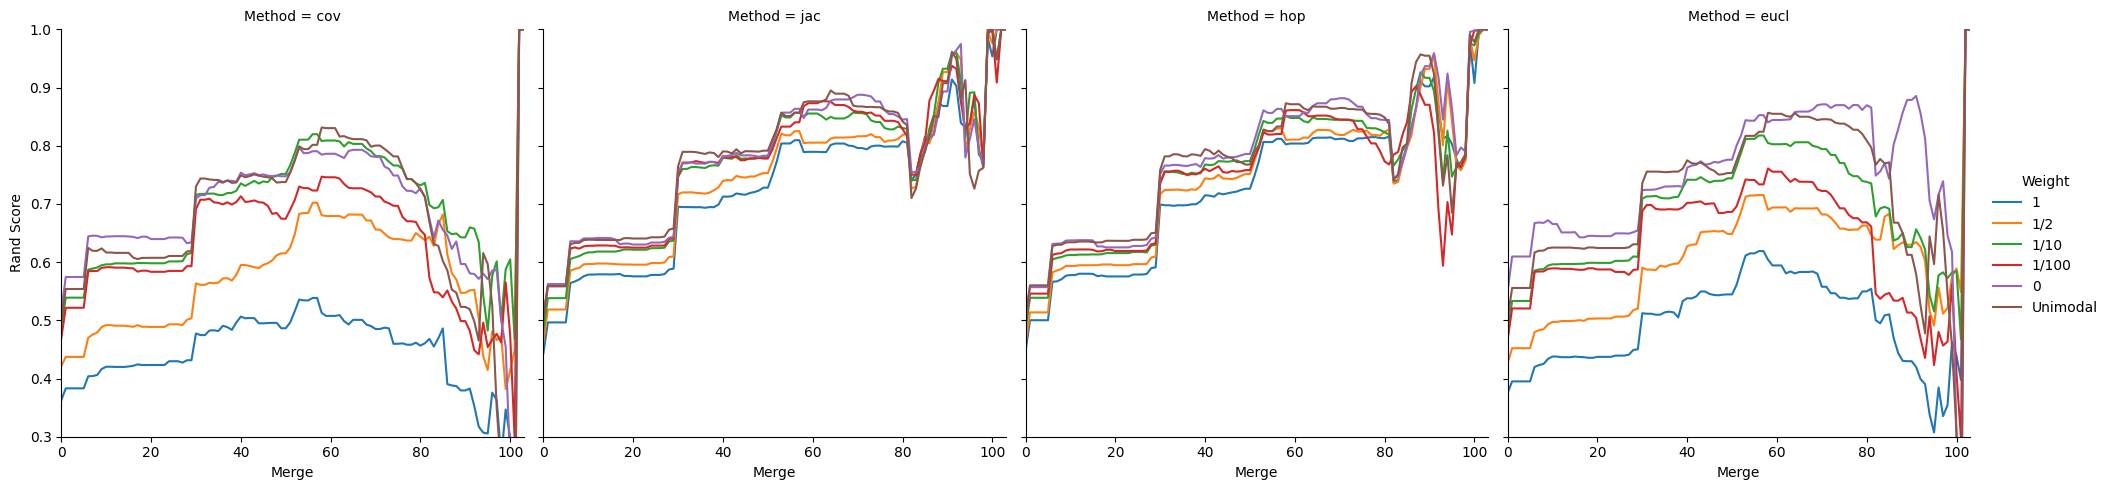

In [170]:
plot_data = {"Merge": [], score_name: [], "Weight": [], "Method": []}
for (weight, method_dict) in scores.items():
    for (method, modal_dict) in method_dict.items():
        if method == "raw": continue
        for (merge, score) in modal_dict[("T", "T")].items():
            plot_data["Merge"].append(merge)
            plot_data[score_name].append(score)
            plot_data["Weight"].append(weight)
            plot_data["Method"].append(method)
plot = sns.relplot(plot_data, x = "Merge", y = score_name, hue = "Weight", col = "Method", kind = "line")
for ax in plot.figure.axes:
    ax.set_xlim((0, 103))
    ax.set_ylim((0.3, 1.0))
plt.show()

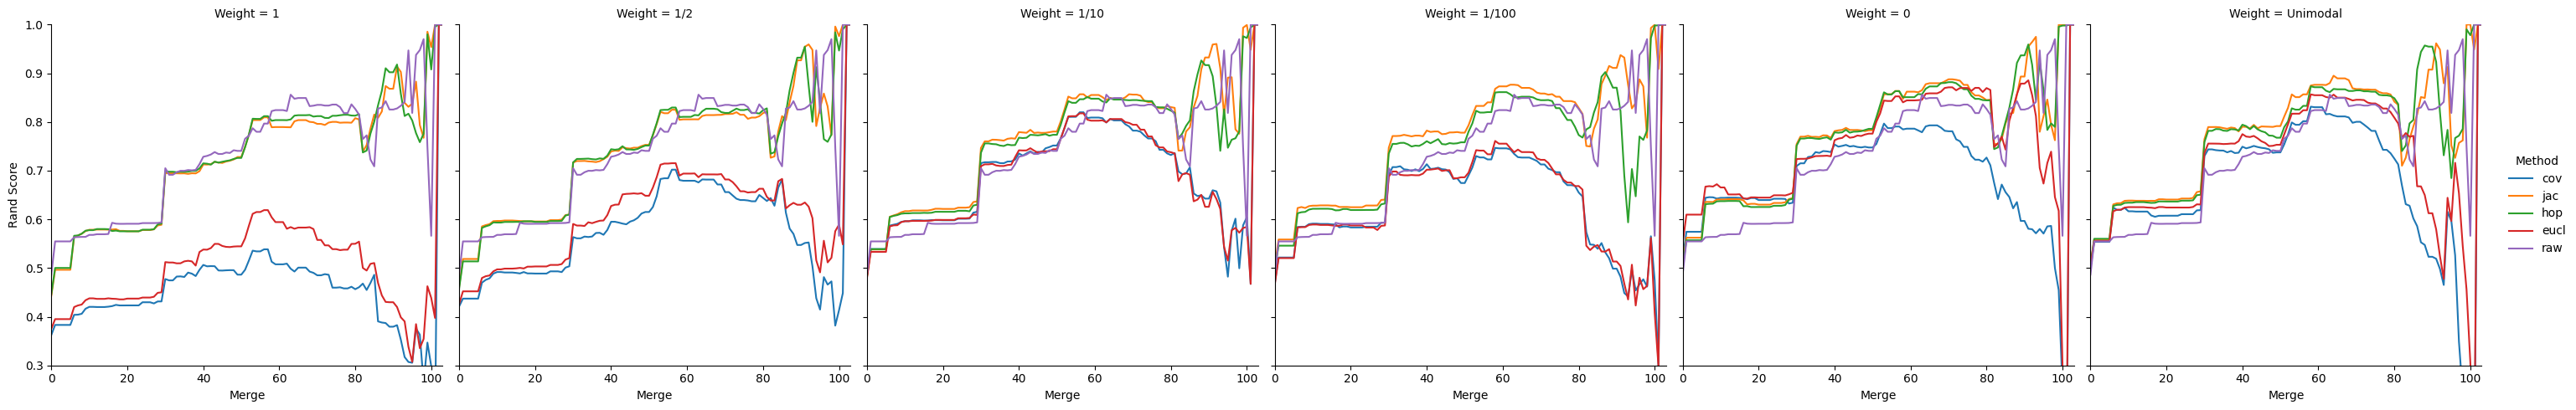

In [5]:
plot_data = {"Merge": [], score_name: [], "Weight": [], "Method": []}
for (weight, method_dict) in scores.items():
    for (method, modal_dict) in method_dict.items():
        # if method == "raw": continue
        for (merge, score) in modal_dict[("T", "T")].items():
            plot_data["Merge"].append(merge)
            plot_data[score_name].append(score)
            plot_data["Weight"].append(weight)
            plot_data["Method"].append(method)
plot = sns.relplot(plot_data, x = "Merge", y = score_name, hue = "Method", col = "Weight", kind = "line")
for ax in plot.figure.axes:
    ax.set_xlim((0, 103))
    ax.set_ylim((0.3, 1.0))
plt.show()

## Silhouette

In [69]:
silhouettes = {weight: get_silhouette(data["logcpm"], pred) for (weight, (pred, _)) in labels.items()}

In [72]:
t_type_silhouettes = {}
for merge in labels["Unimodal"][0]["cov"][("T", "T")]:
    true_merged = get_merge_func(merge)(cluster_labels)
    label_map = {label:i for (i, label) in enumerate(np.unique(true_merged))}
    true_indices = np.asarray([label_map[label] for label in true_merged])
    if len(label_map) > 1:
        t_type_silhouettes[merge] = silhouette_score(data["logcpm"], true_indices)

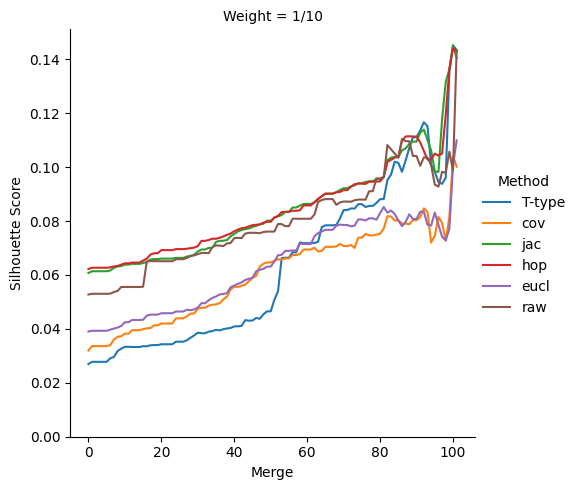

In [73]:
plot_data = {"Silhouette Score": list(t_type_silhouettes.values()), "Merge": list(t_type_silhouettes), 
             "Method": len(t_type_silhouettes)*["T-type"], "Weight": len(t_type_silhouettes)*["1/10"]}
for (weight, method_dict) in silhouettes.items():
    if weight != "1/10": continue
    for (method, modal_dict) in method_dict.items():
        for (merge, score) in modal_dict[("T", "T")].items():
            plot_data["Merge"].append(merge)
            plot_data["Silhouette Score"].append(score)
            plot_data["Weight"].append(weight)
            plot_data["Method"].append(method)
plot = sns.relplot(plot_data, x = "Merge", y = "Silhouette Score", hue = "Method", col = "Weight", kind = "line")
for ax in plot.figure.axes:
    ax.set_ylim((-0.00, None))
plt.show()